In this notebook, we try to solve the one norm problem with cost function 

\begin{equation}
    J(u) = \|Au - b\|_2^2 + \alpha \|u\|_1
\end{equation}

by rewriting it into a least squares problem and using normal equations to solve the leastsquares problem. In each iteration, the least squares problem is

\begin{equation*}
    u_{k+1} = \arg\min_u \left\| \begin{bmatrix}
        A\\
        \sqrt{\alpha} W^{1/2}_k
    \end{bmatrix}u - \begin{bmatrix}
        b\\
        0
    \end{bmatrix}\right\|_2^2
\end{equation*}

with $W_k = \text{diag}\{u^{-1}_k\}$

The normal equations are given as 

\begin{equation}
    (A^TA + \alpha W_k)^{-1}A^Tb = u
\end{equation}

In [2]:
# import necessary packages

# CIL imports
from cil.framework import ImageGeometry, AcquisitionGeometry, BlockDataContainer, ImageData

# From cil.plugins import TomoPhantom
from phantominator import shepp_logan

from cil.optimisation.functions import LeastSquares, L2NormSquared

# For display
from cil.utilities.display import show2D, show1D, show_geometry

# ASTRA imports
from cil.plugins.astra.operators import ProjectionOperator

from cil.optimisation.algorithms import CGLS, GD

# External imports
import numpy as np
import matplotlib.pyplot as plt
import logging

from cil.optimisation.operators import BlockOperator, DiagonalOperator, CompositionOperator

import scipy as sp

In [3]:
# setting pixels and angles
n_pixels = 256
n_angles = 50

## Setting up phantom system and defaults

In [4]:
# Set logging level for CIL processors:
logging.basicConfig(level=logging.WARNING)
cil_log_level = logging.getLogger('cil.processors')
cil_log_level.setLevel(logging.INFO)

# Setting background defaults
cmap = "rainbow"
device = "cpu"

In [5]:
# Angles
angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)

# Setup acquisition geometry
ag = AcquisitionGeometry.create_Parallel2D()\
                            .set_angles(angles)\
                            .set_panel(n_pixels, pixel_size=1/n_pixels)

# Setup image geometry
ig = ImageGeometry(voxel_num_x=n_pixels, 
                   voxel_num_y=n_pixels, 
                   voxel_size_x=1/n_pixels, 
                   voxel_size_y=1/n_pixels)

# Get phantom
phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)

# Create projection operator using Astra-Toolbox.
A = ProjectionOperator(ig, ag, device)

# Create an acquisition data (numerically)
sino = A.direct(phantom)

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


## Solving by self implementation of CG

In [6]:
def apply_operator(x, W, alpha):

    """
    Applies the operator 
    
    A^TA + alpha * W 
    
    to the input ImageData x. Used to solve the normal equations 

    (R^TR + alpha * W_k)u = R^Ty

    with W_k = u_k**(-1)

    Input:
        x:  ImageData to which the operator is applied
        W:  Weights
        alpha:  regularisation parameter

    Output:
        z: ImageData (A^TA + alpha * W)x
    """
    
    # z2 = (A^TA)x
    z1 = A.direct(x)
    z2 = A.adjoint(z1)

    # z3 = Wx
    w_operator = DiagonalOperator(W)
    z3 = w_operator.direct(x)

    z = z2 + alpha * z3

    return z

In [7]:
def CG(initial, iteration, b, alpha, Wk):

    """
    Solves for u in the system 

    (A^TA + alpha * W_k)u = A^Ty

    using CG

    Input:
        initial:    initial guess for u (ImageData)
        iteration:  maximum number of iterations used (integer)
        b:          lhs, that is A^Tb (ImageData)
        alpha:      regularisation parameter (float)
        W_k:        weights (ImageData)
    """

    u0 = initial.copy()
    r0 = b - apply_operator(u0, Wk, alpha)
    p0 = r0

    # set initials, note these are all of class <ImageData> 
    pk = p0
    uk = u0
    rk = r0
    delta_new = rk.dot(rk.conjugate())

    norm = L2NormSquared()
    r0_norm = norm(r0)
    tol = 1e-2

    # perform CG iterations
    for k in range(iteration):
        zk = apply_operator(pk, Wk, alpha)

        # NOTE: might need to find something better than adding 1e-6
        alpha_k = delta_new/(pk.dot(zk.conjugate()))

        uk_plus_one = uk + alpha_k * pk 
        rk_plus_one = rk - alpha_k * zk

        delta_old = delta_new
        delta_new = rk_plus_one.dot(rk_plus_one.conjugate())

        beta_k = delta_new/delta_old

        pk_plus_one = rk_plus_one + beta_k * pk

        # stopping criteria
        check = norm(rk_plus_one)  # should technically be 'b - Ax'
        if check < tol * r0_norm:
            uk = uk_plus_one
            print(f"cg converged in {k+1} iterations")
            break

        # reset variables
        rk = rk_plus_one
        pk = pk_plus_one
        uk = uk_plus_one

    return uk

In [8]:
def onenorm_normal(max_outer, max_inner, initial, A, b, alpha, er):
    """
    Finds a solution for the problem 

    ||Au - b||_2^2 + alpha * ||u||_1

    by first rewriting the regularisation term into a two norm by a weights matrix W and then solving via
    the normal equations using CG. The normal equations are given by 

    (A^TA + alpha*W_k)u = A^Tb

    In each outer iterations the matrix W_k is updated (reweighted), W_k = u_k^(-1)

    Input:
        max_outer:  Number of outer iterations (scalar)
        max_inner:  Number of CG interations (scalar)
        initial:    Initial guess for u (ImageData)
        A:          The acting operator (Operator)
        b:          The obtained data (AcquisitionData)
        alpha:      Regularization parameter (scalar)
        er:         Upper bound for 'small values' in W_k that will be set to zero (float)

    Output:
        uk:         Reconstructed image (ImageData)
    """

    # setting up LHS of normal equation
    lhs = A.adjoint(b)

    # setting initials
    uk = initial.copy()
    for k in range(max_outer):

        print(f"outer iteration: {k+1}")
        
        ## reweight the regularisation term ##
        uk_grad = uk.abs()
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = uk_grad_np[large_values] ** (-1)

        # convert back to ImageData
        uk_reweighted = ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        # performing CG
        cg_output = CG(uk, max_inner, lhs, alpha, uk_reweighted)

        uk = cg_output

    return uk

## Results

In [30]:
x0 = ig.allocate(0)
alpha = 0.0008
lets_hope = onenorm_normal(10, 15, x0, A, sino, alpha, 0.0001)

outer iteration: 1
cg converged in 2 iterations
outer iteration: 2
outer iteration: 3
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10


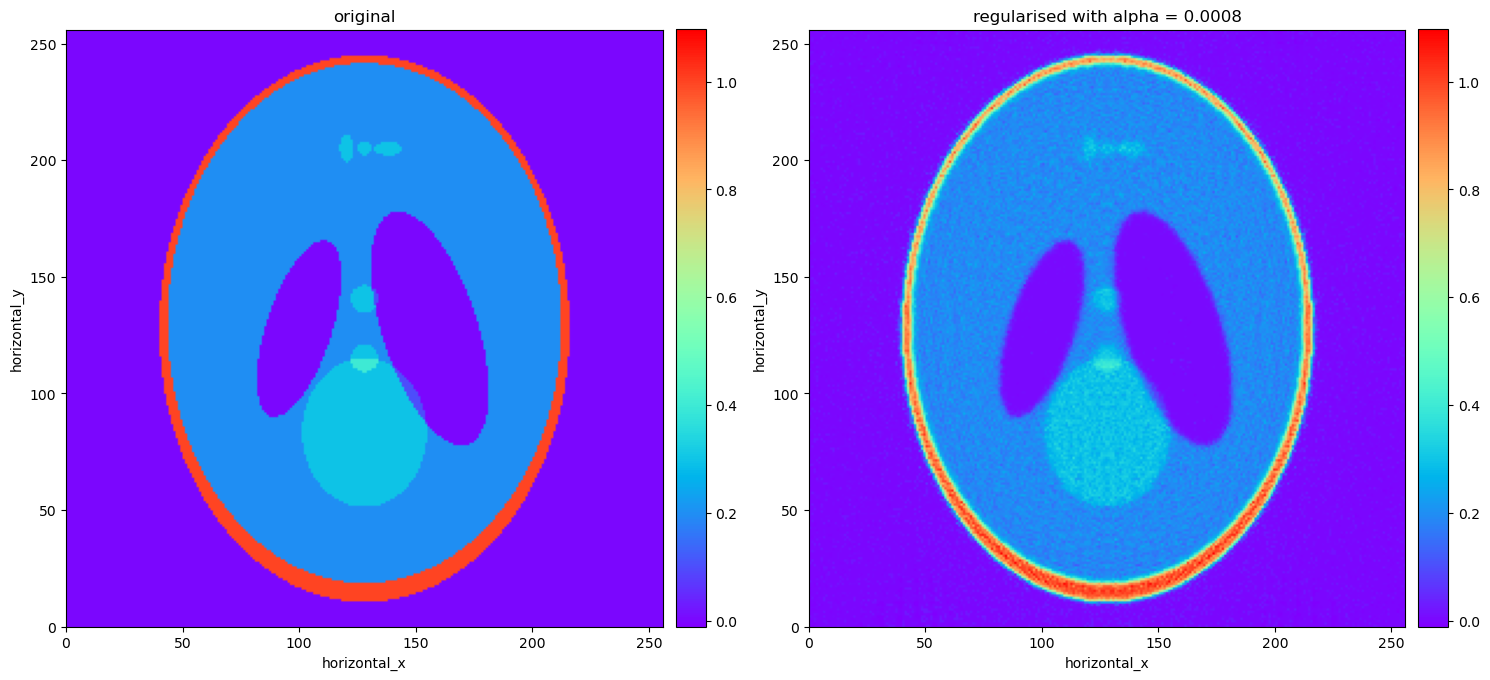

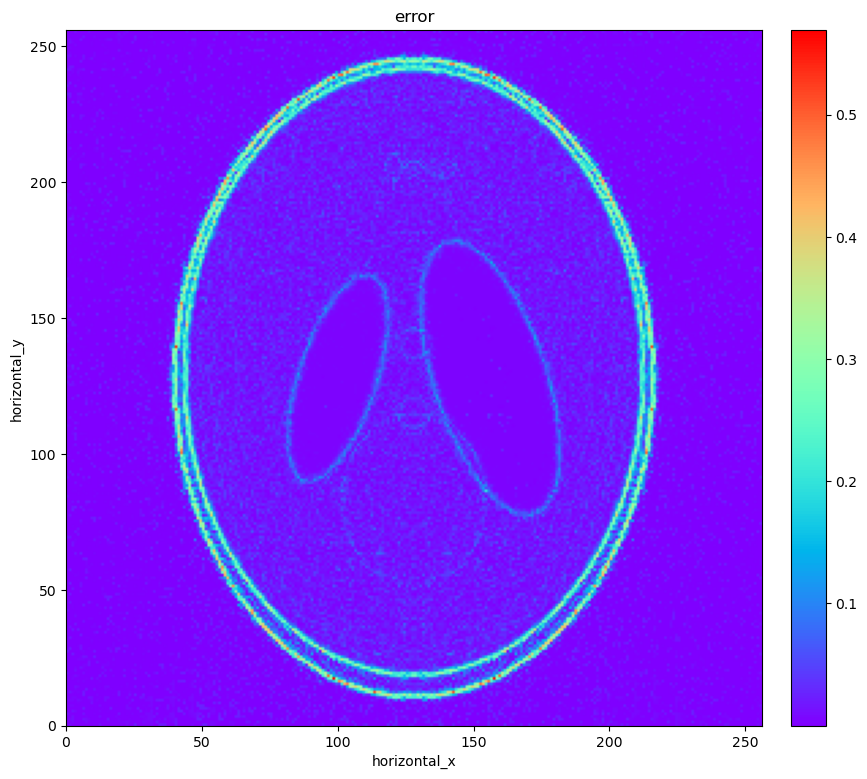

In [31]:
show2D([phantom, lets_hope], 
       ['original', f'regularised with alpha = {alpha}'], 
       cmap=cmap, fix_range=True, num_cols = 2)

show2D([(phantom - lets_hope).abs()], ['error'], cmap=cmap)

outer iteration: 1
cg converged in 2 iterations
outer iteration: 2
outer iteration: 3
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10


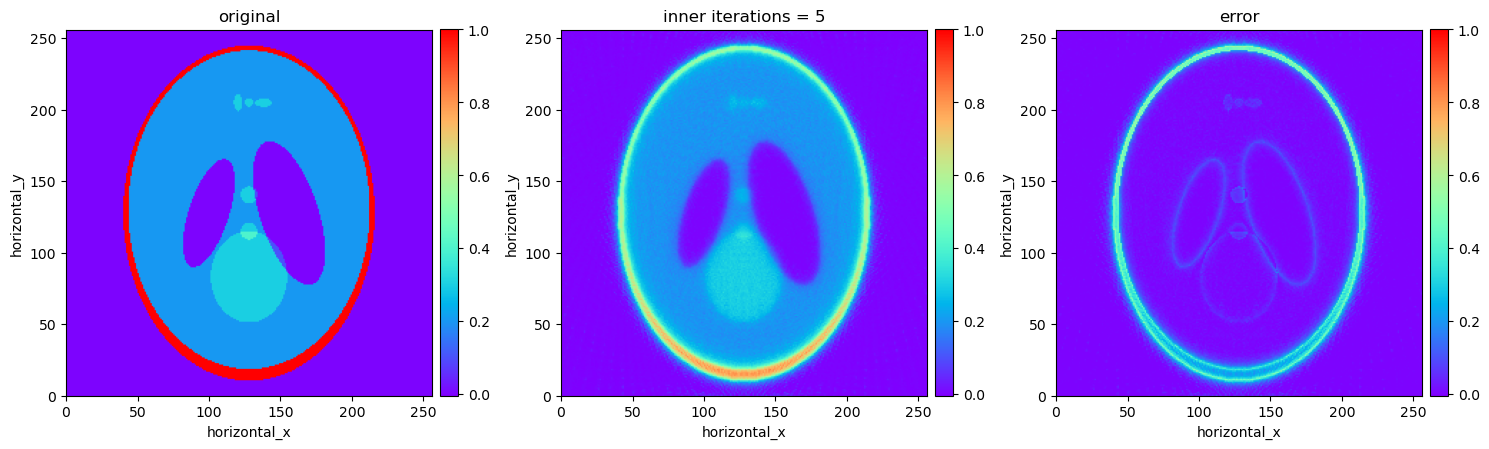

outer iteration: 1
cg converged in 2 iterations
outer iteration: 2
outer iteration: 3
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10


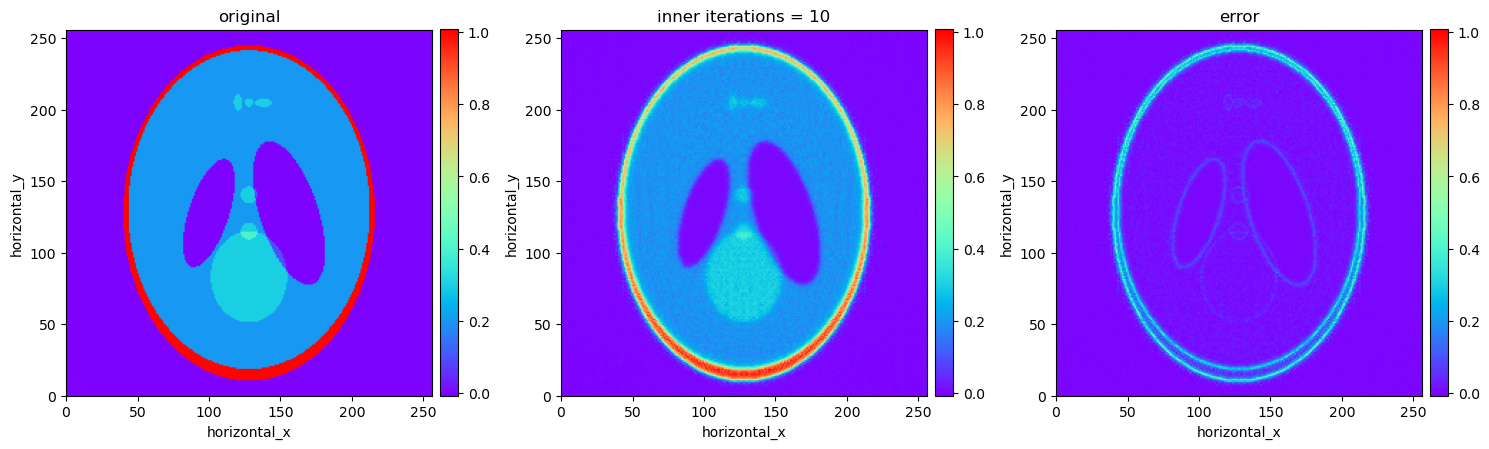

outer iteration: 1
cg converged in 2 iterations
outer iteration: 2
outer iteration: 3
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10


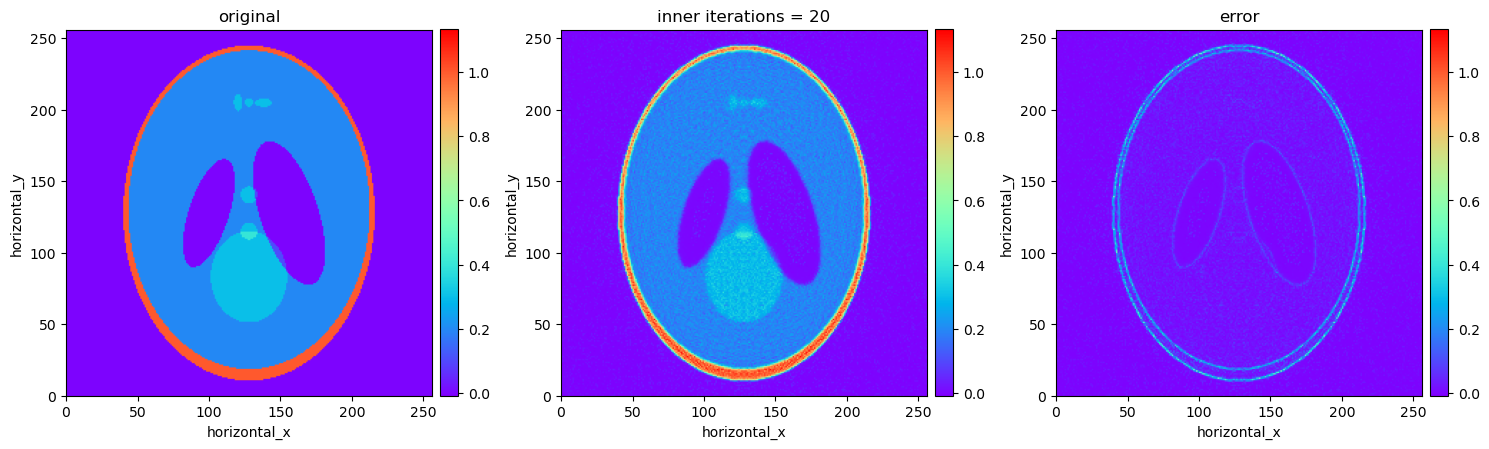

outer iteration: 1
cg converged in 2 iterations
outer iteration: 2
outer iteration: 3
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10


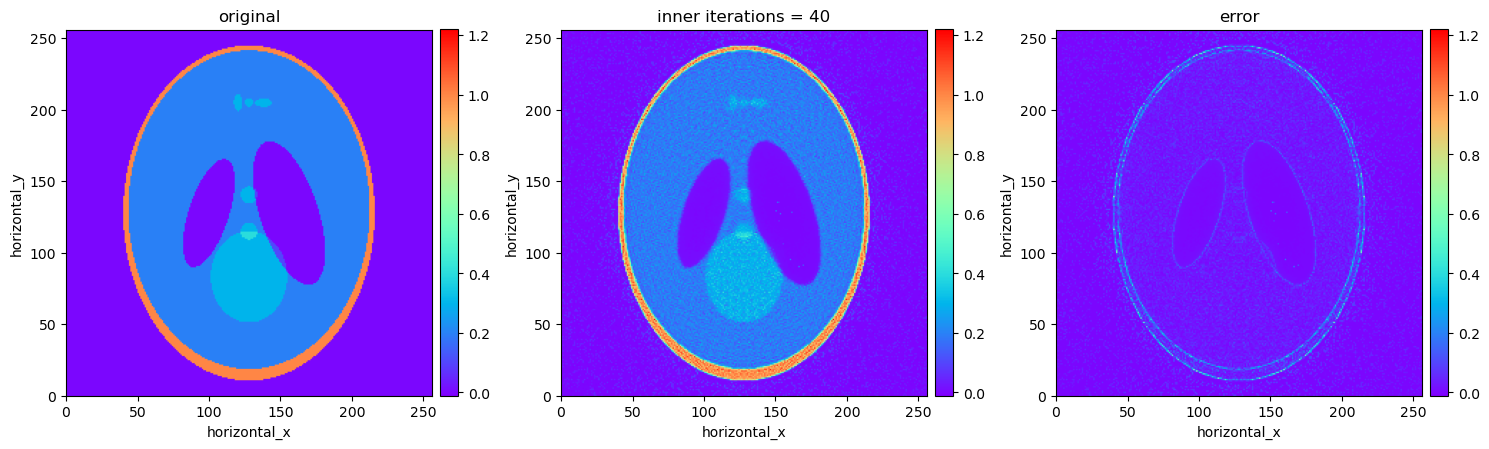

In [25]:
for inner in [5, 10, 20, 40]:
    sol = onenorm_normal(10, inner, x0, A, sino, 0.0008, 0.0001)
    error = (phantom - sol).abs()
    show2D([phantom, sol, error], ['original', f'inner iterations = {inner}', 'error'], cmap=cmap, num_cols=3, fix_range=True)